# Análise Descritiva e Diagnóstica em Epidemiologia

## Estudo prático com dataset fictício

Neste notebook, vamos usar uma base **fake de epidemiologia** para praticar os conceitos de:

- **Análise Descritiva**: responder *o que aconteceu?*
- **Análise Diagnóstica**: investigar *por que isso pode ter acontecido?*

> Observação: os dados são totalmente fictícios e têm finalidade exclusivamente didática.


## 1. Importação das bibliotecas

Usaremos `pandas`, `numpy` e `matplotlib`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)


## 2. Carregamento da base

A base contém registros fictícios de pacientes, com variáveis demográficas, exposição, estilo de vida e desfechos clínicos.


In [2]:
df = pd.read_csv("dataset_epidemiologia_fake.csv")
df.head()


,Paciente_ID,Idade,Sexo,Regiao,Mes_Diagnostico,Tabagismo,Exposicao,Atividade_Fisica,Vacinado,Comorbidade,IMC,Dias_Sintomas,Marcador_Inflamatorio,Internacao,Desfecho_Grave
0,1,38,Masculino,Norte,Abr,Não,Não exposto,Baixa,Não,Sim,36.40,6,4.16,Não,Não
1,2,21,Feminino,Sul,Jun,Não,Não exposto,Alta,Sim,Não,26.70,8,4.59,Não,Não
2,3,52,Masculino,Norte,Abr,Não,Não exposto,Alta,Sim,Não,27.80,4,4.05,Não,Não
3,4,46,Feminino,Sul,Abr,Não,Não exposto,Baixa,Não,Sim,27.90,5,3.95,Não,Não
4,5,72,Feminino,Leste,Mai,Não,Não exposto,Moderada,Sim,Não,23.00,4,3.29,Não,Não


## 3. Visão geral da estrutura da base

Antes de interpretar os dados, precisamos entender:

- Quantas linhas e colunas existem?
- Quais são os tipos de dados?
- Existem valores ausentes?


In [ ]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas: 600
Colunas: 15


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Paciente_ID            600 non-null    int64  
 1   Idade                  600 non-null    int64  
 2   Sexo                   600 non-null    str    
 3   Regiao                 600 non-null    str    
 4   Mes_Diagnostico        600 non-null    str    
 5   Tabagismo              600 non-null    str    
 6   Exposicao              600 non-null    str    
 7   Atividade_Fisica       600 non-null    str    
 8   Vacinado               600 non-null    str    
 9   Comorbidade            600 non-null    str    
 10  IMC                    582 non-null    float64
 11  Dias_Sintomas          600 non-null    int64  
 12  Marcador_Inflamatorio  600 non-null    float64
 13  Internacao             600 non-null    str    
 14  Desfecho_Grave         600 non-null    str    
dtypes: float64(2), in

In [ ]:
df.isnull().sum()

Paciente_ID               0
Idade                     0
Sexo                      0
Regiao                    0
Mes_Diagnostico           0
Tabagismo                 0
Exposicao                 0
Atividade_Fisica          0
Vacinado                  0
Comorbidade               0
IMC                      18
Dias_Sintomas             0
Marcador_Inflamatorio     0
Internacao                0
Desfecho_Grave            0
dtype: int64

# 🔹 PARTE 1 — ANÁLISE DESCRITIVA

## Pergunta central: o que aconteceu?

A análise descritiva resume e organiza os dados para tornar o cenário compreensível.

Nesta etapa, ainda não estamos tentando explicar causas. Estamos descrevendo o comportamento da base.


## 4. Estatísticas descritivas gerais

A função `describe()` mostra medidas como média, desvio padrão, mínimo, quartis e máximo.


In [ ]:
df.describe()

,Paciente_ID,Idade,IMC,Dias_Sintomas,Marcador_Inflamatorio
count,600.00,600.00,582.00,600.00,600.00
mean,300.50,47.36,26.70,7.78,3.71
std,173.35,17.26,4.37,3.85,1.28
min,1.00,18.00,17.00,1.00,0.20
25%,150.75,35.00,23.73,5.00,2.83
50%,300.50,48.00,26.50,7.00,3.67
75%,450.25,59.00,29.80,9.00,4.48
max,600.00,90.00,38.20,36.00,8.78


## 5. Medidas numéricas principais

Vamos calcular:

- Média
- Mediana
- Desvio padrão
- Mínimo
- Máximo
- Intervalo

Essas medidas ajudam a entender tendência central, dispersão e valores extremos.


In [ ]:
variaveis_numericas = [
    "Idade",
    "IMC",
    "Dias_Sintomas",
    "Marcador_Inflamatorio"
]

resumo_descritivo = pd.DataFrame({
    "Média": df[variaveis_numericas].mean(),
    "Mediana": df[variaveis_numericas].median(),
    "Desvio Padrão": df[variaveis_numericas].std(),
    "Mínimo": df[variaveis_numericas].min(),
    "Máximo": df[variaveis_numericas].max()
})

resumo_descritivo["Intervalo"] = resumo_descritivo["Máximo"] - resumo_descritivo["Mínimo"]

resumo_descritivo

,Média,Mediana,Desvio Padrão,Mínimo,Máximo,Intervalo
Idade,47.36,48.00,17.26,18.00,90.00,72.00
IMC,26.70,26.50,4.37,17.00,38.20,21.20
Dias_Sintomas,7.78,7.00,3.85,1.00,36.00,35.00
Marcador_Inflamatorio,3.71,3.67,1.28,0.20,8.78,8.58


### Interpretação

- Se a média estiver distante da mediana, pode existir assimetria ou influência de valores extremos.
- Desvio padrão alto indica maior variabilidade.
- Intervalo muito grande pode sinalizar dispersão elevada ou outliers.


## 6. Frequências das variáveis categóricas

Em epidemiologia, muitas variáveis são categóricas:

- sexo;
- região;
- exposição;
- vacinação;
- comorbidade;
- internação;
- desfecho grave.

Vamos contar a frequência de cada categoria.


In [ ]:
categoricas = [
    "Sexo",
    "Regiao",
    "Exposicao",
    "Vacinado",
    "Comorbidade",
    "Internacao",
    "Desfecho_Grave"
]

for coluna in categoricas:
    print(f"\n{coluna}")
    print(df[coluna].value_counts())


Sexo
Sexo
Feminino     308
Masculino    292
Name: count, dtype: int64

Regiao
Regiao
Leste     147
Oeste     123
Sul       120
Norte     112
Centro     98
Name: count, dtype: int64

Exposicao
Exposicao
Não exposto    415
Exposto        185
Name: count, dtype: int64

Vacinado
Vacinado
Sim    393
Não    207
Name: count, dtype: int64

Comorbidade
Comorbidade
Não    365
Sim    235
Name: count, dtype: int64

Internacao
Internacao
Não    551
Sim     49
Name: count, dtype: int64

Desfecho_Grave
Desfecho_Grave
Não    586
Sim     14
Name: count, dtype: int64


## 7. Proporção de internação e desfecho grave

Além da frequência absoluta, a proporção ajuda a interpretar a magnitude do evento.


In [ ]:
taxa_internacao = (df["Internacao"] == "Sim").mean() * 100
taxa_desfecho_grave = (df["Desfecho_Grave"] == "Sim").mean() * 100

print(f"Taxa de internação: {taxa_internacao:.1f}%")
print(f"Taxa de desfecho grave: {taxa_desfecho_grave:.1f}%")

Taxa de internação: 8.2%
Taxa de desfecho grave: 2.3%


## 8. Gráfico de barras — casos por região

Gráficos de barras ajudam a organizar a análise descritiva por grupos.


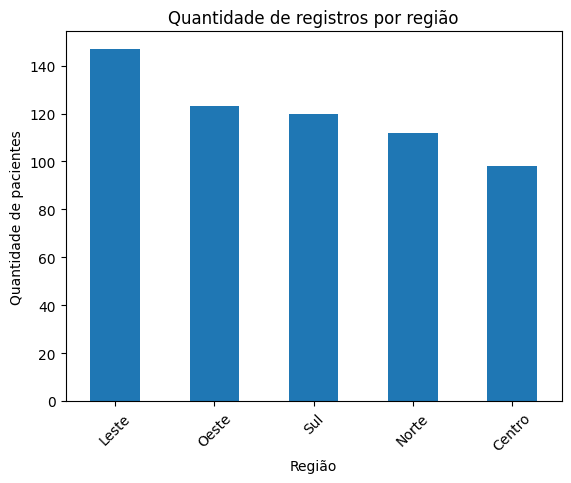

In [ ]:
df["Regiao"].value_counts().plot(kind="bar")

plt.title("Quantidade de registros por região")
plt.xlabel("Região")
plt.ylabel("Quantidade de pacientes")
plt.xticks(rotation=45)
plt.show()

## 9. Gráfico de barras — internação

Vamos visualizar a quantidade de pacientes internados e não internados.


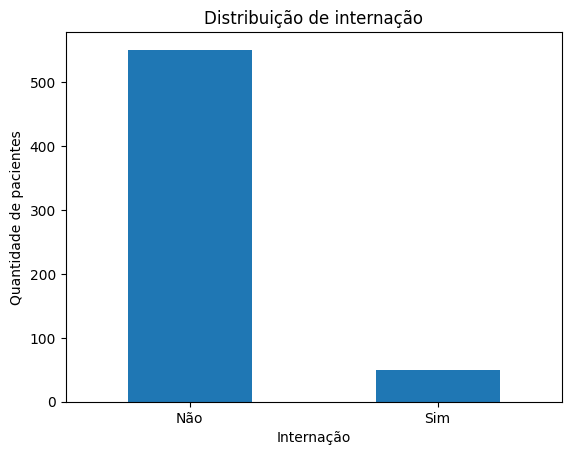

In [ ]:
df["Internacao"].value_counts().plot(kind="bar")

plt.title("Distribuição de internação")
plt.xlabel("Internação")
plt.ylabel("Quantidade de pacientes")
plt.xticks(rotation=0)
plt.show()

## 10. Histograma — idade

O histograma ajuda a visualizar a distribuição de uma variável numérica.


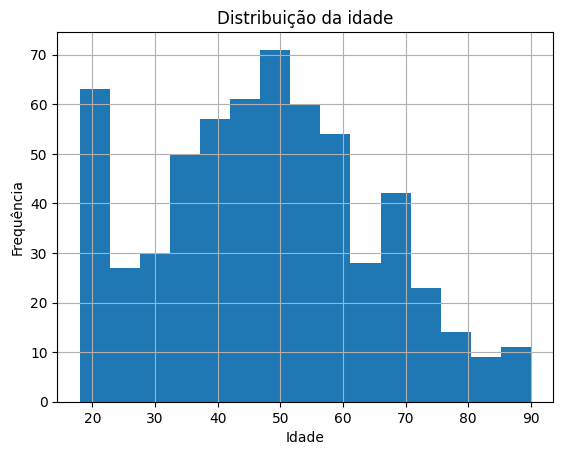

In [ ]:
df["Idade"].hist(bins=15)

plt.title("Distribuição da idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

## 11. Boxplot — dias de sintomas

O boxplot ajuda a visualizar mediana, quartis, dispersão e possíveis valores extremos.


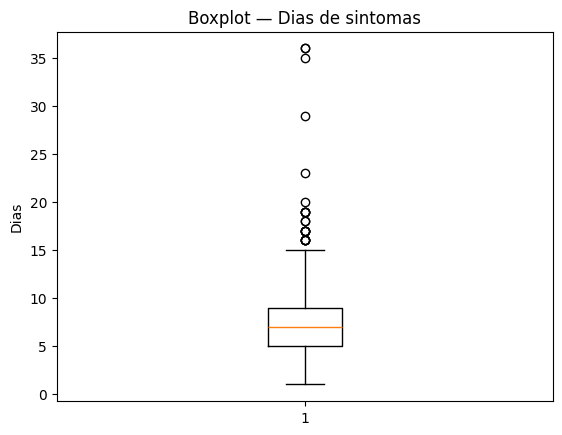

In [ ]:
plt.boxplot(df["Dias_Sintomas"].dropna())

plt.title("Boxplot — Dias de sintomas")
plt.ylabel("Dias")
plt.show()

## Conclusão descritiva parcial

Até aqui respondemos:

- Qual é o perfil geral da base?
- Qual a média e mediana de idade, IMC, dias de sintomas e marcador inflamatório?
- Qual a proporção de internação e desfecho grave?
- Como os casos se distribuem por região?
- Existem sinais de variabilidade ou valores extremos?

> Essa etapa responde **o que aconteceu**, sem afirmar ainda o porquê.


# PARTE 2 — ANÁLISE DIAGNÓSTICA

## Pergunta central: por que isso pode ter acontecido?

A análise diagnóstica busca investigar relações, diferenças entre grupos e possíveis explicações.

Ela não deve confundir correlação com causalidade, mas ajuda a levantar hipóteses.


## 12. Drill-down — internação por exposição

Vamos comparar a proporção de internação entre expostos e não expostos.

Neste dataset fictício, a variável `Exposicao` representa o grupo exposto ao tabagismo.


In [14]:
internacao_por_exposicao = pd.crosstab(
    df["Exposicao"],
    df["Internacao"],
    normalize="index"
) * 100

internacao_por_exposicao


Internacao,Não,Sim
Exposicao,,
Exposto,90.81,9.19
Não exposto,92.29,7.71


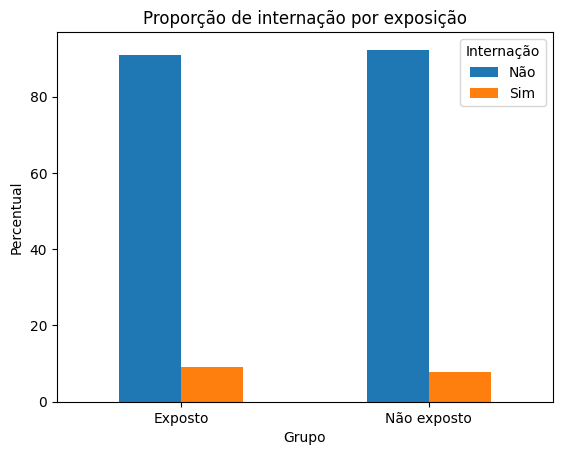

In [15]:
internacao_por_exposicao.plot(kind="bar")

plt.title("Proporção de internação por exposição")
plt.xlabel("Grupo")
plt.ylabel("Percentual")
plt.xticks(rotation=0)
plt.legend(title="Internação")
plt.show()


### Interpretação

Se o grupo exposto apresenta maior proporção de internação, isso pode sugerir uma associação.

Mas atenção:

> Associação não é o mesmo que causalidade.

Pode haver outros fatores, como idade, comorbidades, vacinação ou atividade física.


## 13. Cohort — comparação de grupos expostos e não expostos

A análise de cohort agrupa indivíduos por uma característica comum inicial, como exposição, e compara o desfecho ao longo do tempo.

Neste exemplo:

- **Cohort exposto:** pacientes tabagistas;
- **Grupo de comparação:** pacientes não tabagistas;
- **Desfecho:** internação.


In [16]:
cohort = df.groupby("Exposicao").agg(
    Total=("Paciente_ID", "count"),
    Internacoes=("Internacao", lambda x: (x == "Sim").sum()),
    Desfechos_Graves=("Desfecho_Grave", lambda x: (x == "Sim").sum())
)

cohort["Taxa_Internacao_%"] = cohort["Internacoes"] / cohort["Total"] * 100
cohort["Taxa_Desfecho_Grave_%"] = cohort["Desfechos_Graves"] / cohort["Total"] * 100

cohort


,Total,Internacoes,Desfechos_Graves,Taxa_Internacao_%,Taxa_Desfecho_Grave_%
Exposicao,,,,,
Exposto,185,17,7,9.19,3.78
Não exposto,415,32,7,7.71,1.69


## 14. Risco relativo simples

O risco relativo compara a taxa de ocorrência do desfecho no grupo exposto em relação ao grupo não exposto.

\[
RR = \frac{Risco\ no\ grupo\ exposto}{Risco\ no\ grupo\ não\ exposto}
\]

Se RR > 1, o risco no grupo exposto é maior.


In [17]:
risco_exposto = cohort.loc["Exposto", "Taxa_Internacao_%"] / 100
risco_nao_exposto = cohort.loc["Não exposto", "Taxa_Internacao_%"] / 100

risco_relativo = risco_exposto / risco_nao_exposto

print(f"Risco de internação no grupo exposto: {risco_exposto:.3f}")
print(f"Risco de internação no grupo não exposto: {risco_nao_exposto:.3f}")
print(f"Risco relativo: {risco_relativo:.2f}")


Risco de internação no grupo exposto: 0.092
Risco de internação no grupo não exposto: 0.077
Risco relativo: 1.19


### Interpretação

O risco relativo ajuda a comparar grupos.

Exemplo de leitura:

- RR = 1: riscos semelhantes;
- RR > 1: maior risco no grupo exposto;
- RR < 1: menor risco no grupo exposto.

Mesmo assim, esta análise ainda é simplificada e não controla todos os fatores.


## 15. Drill-down — internação por comorbidade

Agora vamos verificar se pacientes com comorbidade apresentam maior proporção de internação.


In [18]:
internacao_por_comorbidade = pd.crosstab(
    df["Comorbidade"],
    df["Internacao"],
    normalize="index"
) * 100

internacao_por_comorbidade


Internacao,Não,Sim
Comorbidade,,
Não,95.62,4.38
Sim,85.96,14.04


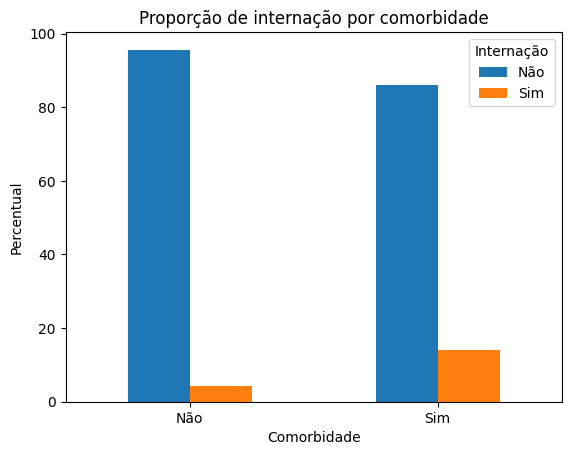

In [19]:
internacao_por_comorbidade.plot(kind="bar")

plt.title("Proporção de internação por comorbidade")
plt.xlabel("Comorbidade")
plt.ylabel("Percentual")
plt.xticks(rotation=0)
plt.legend(title="Internação")
plt.show()


## 16. Segmentação — idade média por desfecho

A segmentação permite comparar grupos.

Vamos comparar a idade média dos pacientes com e sem desfecho grave.


In [20]:
df.groupby("Desfecho_Grave")["Idade"].agg(["count", "mean", "median", "std"])


,count,mean,median,std
Desfecho_Grave,,,,
Não,586,47.10,47.00,17.21
Sim,14,58.43,54.50,16.51


## 17. Correlação entre variáveis numéricas

O mapa de calor ajuda a identificar relações estatísticas entre variáveis numéricas.

A correlação varia de -1 a +1:

- perto de +1: relação positiva forte;
- perto de -1: relação negativa forte;
- perto de 0: pouca relação linear.


In [21]:
corr = df[variaveis_numericas].corr()
corr


,Idade,IMC,Dias_Sintomas,Marcador_Inflamatorio
Idade,1.00,0.04,0.05,0.13
IMC,0.04,1.00,-0.02,-0.01
Dias_Sintomas,0.05,-0.02,1.00,0.24
Marcador_Inflamatorio,0.13,-0.01,0.24,1.00


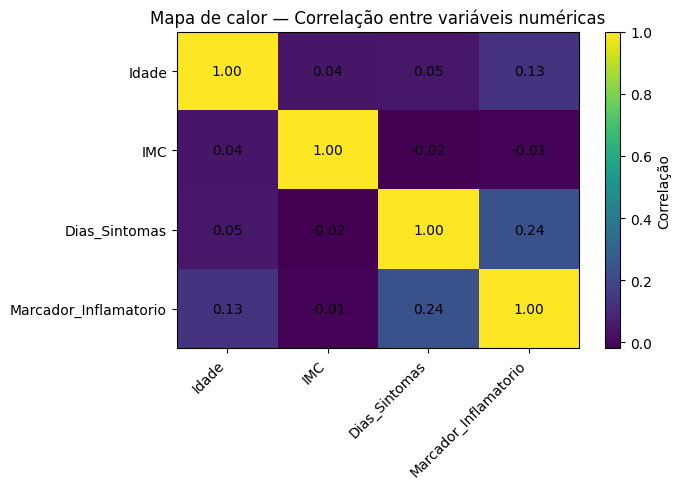

In [22]:
plt.figure(figsize=(7, 5))

plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlação")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        valor = corr.iloc[i, j]
        plt.text(j, i, f"{valor:.2f}", ha="center", va="center")

plt.title("Mapa de calor — Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()


## 18. Gráfico de dispersão — idade × marcador inflamatório

O gráfico de dispersão reforça visualmente a análise de relação.


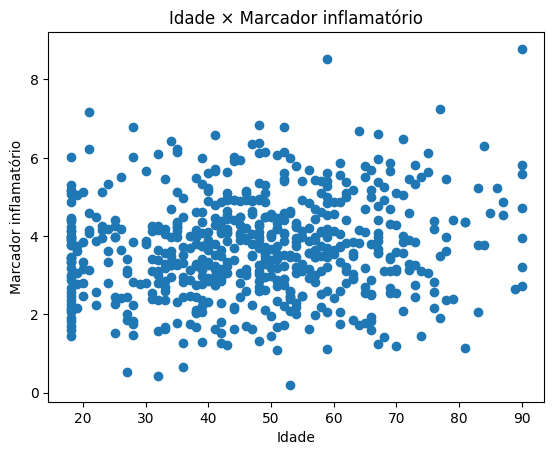

In [23]:
plt.scatter(df["Idade"], df["Marcador_Inflamatorio"])

plt.title("Idade × Marcador inflamatório")
plt.xlabel("Idade")
plt.ylabel("Marcador inflamatório")
plt.show()


## 19. Análise de desvio

A análise de desvio compara cada valor com um padrão esperado.

Neste exemplo, vamos comparar o marcador inflamatório de cada paciente com a média geral.


In [28]:
media_marcador = df["Marcador_Inflamatorio"].mean()

df["Desvio_Marcador"] = df["Marcador_Inflamatorio"] - media_marcador

df[[
    "Paciente_ID",
    "Idade",
    "Comorbidade",
    "Exposicao",
    "Internacao",
    "Desfecho_Grave",
    "Marcador_Inflamatorio",
    "Desvio_Marcador"
]].sort_values("Desvio_Marcador", ascending=False).head(50)


,Paciente_ID,Idade,Comorbidade,Exposicao,Internacao,Desfecho_Grave,Marcador_Inflamatorio,Desvio_Marcador
274,275,90,Sim,Exposto,Sim,Sim,8.78,5.07
441,442,59,Sim,Não exposto,Sim,Sim,8.51,4.80
174,175,77,Não,Não exposto,Não,Não,7.24,3.53
83,84,21,Sim,Não exposto,Sim,Não,7.16,3.45
144,145,48,Não,Não exposto,Sim,Não,6.83,3.12
429,430,52,Sim,Exposto,Não,Sim,6.79,3.08
51,52,28,Não,Não exposto,Não,Não,6.78,3.07
384,385,64,Sim,Não exposto,Não,Não,6.69,2.98
415,416,67,Sim,Não exposto,Não,Não,6.62,2.91
270,271,41,Não,Não exposto,Não,Não,6.59,2.88


## 20. Análise de sensibilidade simples

A análise de sensibilidade pergunta:

> Se uma variável de entrada mudar, o quanto isso altera o resultado?

Vamos criar um exemplo simplificado de risco médio estimado.

Este não é um modelo clínico real. É apenas uma fórmula didática para demonstrar sensibilidade.


In [25]:
# Fórmula didática fictícia
# Risco estimado aumenta com idade, comorbidade e marcador inflamatório
risco_base = 0.10
peso_idade = 0.003
peso_comorbidade = 0.12
peso_marcador = 0.04

idade_media = df["Idade"].mean()
marcador_medio = df["Marcador_Inflamatorio"].mean()
taxa_comorbidade = (df["Comorbidade"] == "Sim").mean()

risco_estimado = (
    risco_base
    + peso_idade * idade_media
    + peso_comorbidade * taxa_comorbidade
    + peso_marcador * marcador_medio
)

print(f"Risco médio estimado: {risco_estimado:.3f}")


Risco médio estimado: 0.437


In [26]:
# Cenário 1: aumento de 10% na idade média
risco_idade_10 = (
    risco_base
    + peso_idade * (idade_media * 1.10)
    + peso_comorbidade * taxa_comorbidade
    + peso_marcador * marcador_medio
)

# Cenário 2: aumento de 10% no marcador inflamatório médio
risco_marcador_10 = (
    risco_base
    + peso_idade * idade_media
    + peso_comorbidade * taxa_comorbidade
    + peso_marcador * (marcador_medio * 1.10)
)

sensibilidade = pd.DataFrame({
    "Cenário": [
        "Base",
        "Idade média +10%",
        "Marcador inflamatório +10%"
    ],
    "Risco_Estimado": [
        risco_estimado,
        risco_idade_10,
        risco_marcador_10
    ]
})

sensibilidade["Variação_vs_Base"] = sensibilidade["Risco_Estimado"] - risco_estimado

sensibilidade


,Cenário,Risco_Estimado,Variação_vs_Base
0,Base,0.44,0.00
1,Idade média +10%,0.45,0.01
2,Marcador inflamatório +10%,0.45,0.01


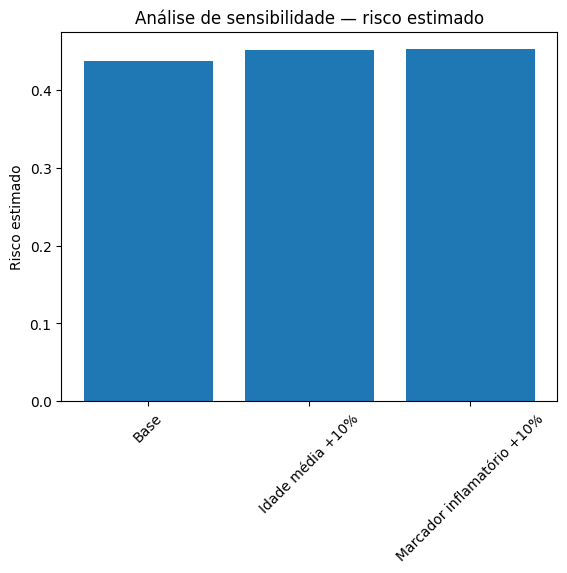

In [27]:
plt.bar(sensibilidade["Cenário"], sensibilidade["Risco_Estimado"])

plt.title("Análise de sensibilidade — risco estimado")
plt.ylabel("Risco estimado")
plt.xticks(rotation=45)
plt.show()


### Interpretação

A análise de sensibilidade mostra qual variável altera mais o resultado quando sofre uma mudança controlada.

Isso ajuda a identificar variáveis críticas, que merecem maior atenção na coleta, monitoramento e análise.


## 21. Exemplo de causa-raiz — 5 Porquês

Problema observado:

> Pacientes com desfecho grave apresentam marcador inflamatório médio mais alto.

1. Por que o marcador está mais alto?  
   Porque esses pacientes apresentam maior intensidade de resposta inflamatória.

2. Por que isso pode ocorrer?  
   Pode estar associado a idade, comorbidades ou exposição.

3. Por que idade e comorbidades importam?  
   Porque podem aumentar a vulnerabilidade clínica.

4. Por que precisamos segmentar?  
   Porque a média geral pode esconder grupos de maior risco.

5. Qual ação analítica?  
   Comparar grupos, controlar variáveis e investigar relações com métodos mais robustos.


# Conclusão final

## Análise Descritiva

Respondemos **o que aconteceu**:

- perfil geral da base;
- distribuição por região, exposição e desfechos;
- média, mediana, desvio padrão e intervalo;
- proporções de internação e desfecho grave;
- visualizações de distribuição e dispersão.

## Análise Diagnóstica

Investigamos **por que pode ter acontecido**:

- comparação entre cohorts;
- risco relativo simples;
- drill-down por exposição e comorbidade;
- segmentação por desfecho;
- correlação entre variáveis;
- análise de desvio;
- análise de sensibilidade;
- raciocínio de causa-raiz.

> A análise descritiva organiza o cenário.  
> A análise diagnóstica ajuda a levantar hipóteses explicativas.
